# Zero-Shot BLIP Captioning on Flickr8k Samples

This notebook loads a pretrained BLIP model (no fine-tuning) and generates captions on 5-10 sample Flickr8k images to evaluate baseline performance before any training.

In [11]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

print("✅ BLIP model loaded successfully")

Using device: cpu


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

✅ BLIP model loaded successfully


In [12]:
df = pd.read_csv("../data/captions.txt", sep="|")
df.columns = df.columns.str.strip()

image_folder = "../data/Images"
sample_images = df['image_name'].unique()[:8]  # 8 sample images

print("Selected images:", sample_images)


Selected images: <ArrowStringArray>
['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg',
 '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg',
 '1007129816_e794419615.jpg', '1007320043_627395c3d8.jpg',
 '1009434119_febe49276a.jpg', '1012212859_01547e3f17.jpg']
Length: 8, dtype: str


In [13]:
def generate_caption(image_path):
    raw_image = Image.open(image_path).convert("RGB")
    inputs = processor(raw_image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=30)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption, raw_image

results = []
for img_name in sample_images:
    img_path = os.path.join(image_folder, img_name)
    generated_caption, img = generate_caption(img_path)
    
    # Ground truth caption (dataset se, comparison ke liye)
    ground_truth = df[df['image_name'] == img_name]['caption_text'].iloc[0]
    
    results.append({
        "image": img_name,
        "generated_caption": generated_caption,
        "ground_truth_caption": ground_truth
    })
    print(f"{img_name}\nGenerated: {generated_caption}\nGround Truth: {ground_truth}\n{'-'*60}")

1000268201_693b08cb0e.jpg
Generated: a little girl in a pink dress
Ground Truth: A child in a pink dress is climbing up a set of stairs in an entry way .
------------------------------------------------------------
1001773457_577c3a7d70.jpg
Generated: two dogs playing on the road
Ground Truth: A black dog and a spotted dog are fighting
------------------------------------------------------------
1002674143_1b742ab4b8.jpg
Generated: a child sitting in the grass
Ground Truth: A little girl covered in paint sits in front of a painted rainbow with her hands in a bowl .
------------------------------------------------------------
1003163366_44323f5815.jpg
Generated: a woman laying on a bench
Ground Truth: A man lays on a bench while his dog sits by him .
------------------------------------------------------------
1007129816_e794419615.jpg
Generated: man wearing a hat
Ground Truth: A man in an orange hat starring at something .
------------------------------------------------------------
10

In [14]:
results_df = pd.DataFrame(results)
results_df

,image,generated_caption,ground_truth_caption
0,1000268201_693b08cb0e.jpg,a little girl in a pink dress,A child in a pink dress is climbing up a set o...
1,1001773457_577c3a7d70.jpg,two dogs playing on the road,A black dog and a spotted dog are fighting
2,1002674143_1b742ab4b8.jpg,a child sitting in the grass,A little girl covered in paint sits in front o...
3,1003163366_44323f5815.jpg,a woman laying on a bench,A man lays on a bench while his dog sits by him .
4,1007129816_e794419615.jpg,man wearing a hat,A man in an orange hat starring at something .
5,1007320043_627395c3d8.jpg,a young girl climbing on a rope,A child playing on a rope net .
6,1009434119_febe49276a.jpg,a dog running in a field,A black and white dog is running in a grassy g...
7,1012212859_01547e3f17.jpg,a dog playing with a ball,"A dog shakes its head near the shore , a red b..."


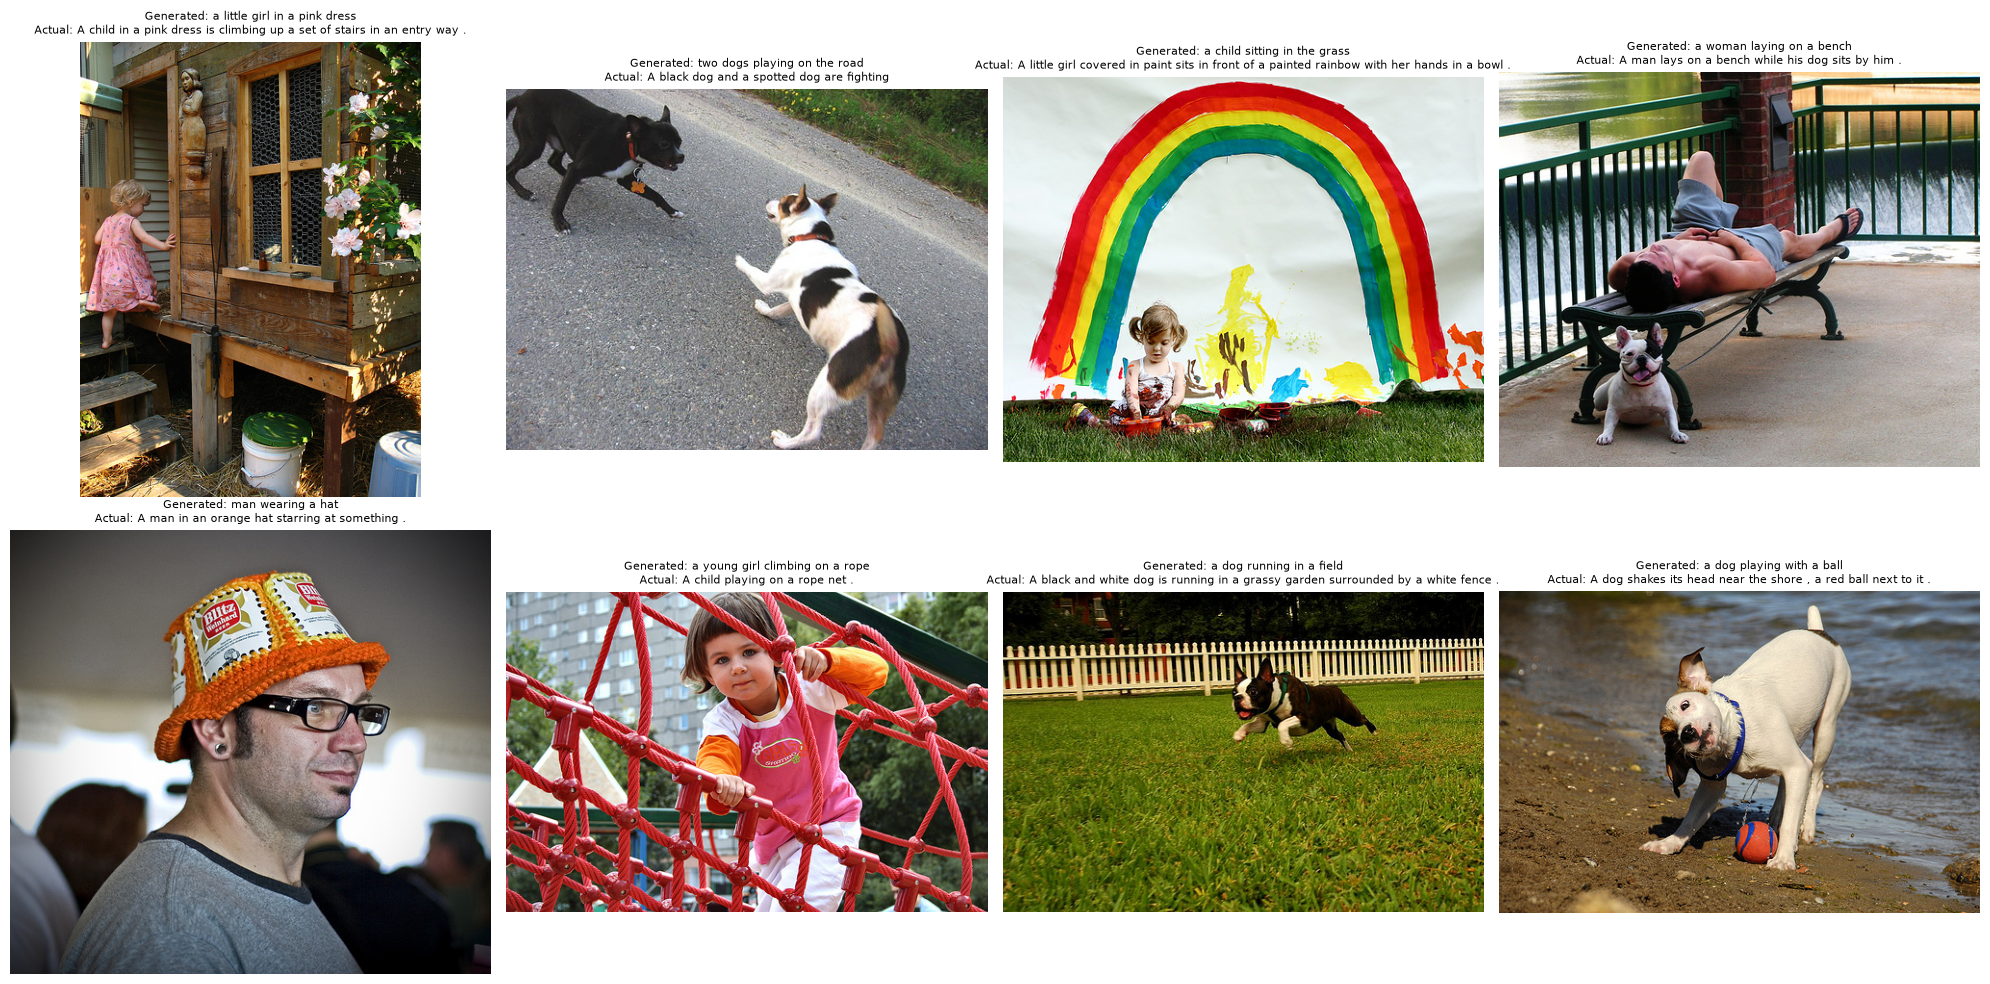

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, row in results_df.iterrows():
    img_path = os.path.join(image_folder, row['image'])
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')
    title = f"Generated: {row['generated_caption']}\nActual: {row['ground_truth_caption']}"
    axes[i].set_title(title, fontsize=8, wrap=True)

plt.tight_layout()
plt.savefig("../data/processed/blip_zero_shot_samples.png")
plt.show()

In [16]:
os.makedirs("../data/processed", exist_ok=True)
results_df.to_csv("../data/processed/blip_zero_shot_results.csv", index=False)
print("✅ Results saved to data/processed/blip_zero_shot_results.csv")

✅ Results saved to data/processed/blip_zero_shot_results.csv
